# One-line CNN vectorisation — Option B improved

This notebook trains a CNN to convert a 64×64 black-and-white raster image containing one line into vector coordinates.

It uses two stages:

1. **Coordinate pre-training**: the CNN first learns `[x1, y1, x2, y2]` directly.
2. **Differentiable raster backpropagation**: the predicted vector is rasterised inside TensorFlow, then compared against the original raster image.

Run the notebook from top to bottom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from PIL import Image, ImageDraw

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Settings

Increase `VECTOR_EPOCHS` or `RASTER_EPOCHS` if you want more training cycles.

In [2]:
IMG_SIZE = 64

N_TRAIN = 5000
N_TEST = 1000

VECTOR_EPOCHS = 150
RASTER_EPOCHS = 200

BATCH_SIZE = 32

np.random.seed(42)
tf.random.set_seed(42)

## Create synthetic training data

Each sample contains one black line on a white background.

The label is the vector form:

```text
[x1, y1, x2, y2]
```

All coordinates are normalised between 0 and 1.

In [3]:
def create_line_image(img_size=64, min_length=12):
    """Create one 64x64 raster image containing a single black line.
    
    Returns:
        image_array: shape (64, 64, 1), values from 0 to 1
        label: shape (4,), normalised [x1, y1, x2, y2]
    """
    while True:
        x1, y1 = np.random.randint(0, img_size, size=2)
        x2, y2 = np.random.randint(0, img_size, size=2)
        length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        if length >= min_length:
            break

    image = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(image)
    draw.line((x1, y1, x2, y2), fill=0, width=1)

    image_array = np.array(image).astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=-1)

    label = np.array([
        x1 / (img_size - 1),
        y1 / (img_size - 1),
        x2 / (img_size - 1),
        y2 / (img_size - 1),
    ], dtype="float32")

    return image_array, label


def create_dataset(n_samples, img_size=64):
    images = []
    labels = []

    for _ in range(n_samples):
        image, label = create_line_image(img_size=img_size)
        images.append(image)
        labels.append(label)

    return np.array(images), np.array(labels)

In [4]:
X_train, y_train = create_dataset(N_TRAIN, IMG_SIZE)
X_test, y_test = create_dataset(N_TEST, IMG_SIZE)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5000, 64, 64, 1)
y_train: (5000, 4)
X_test: (1000, 64, 64, 1)
y_test: (1000, 4)


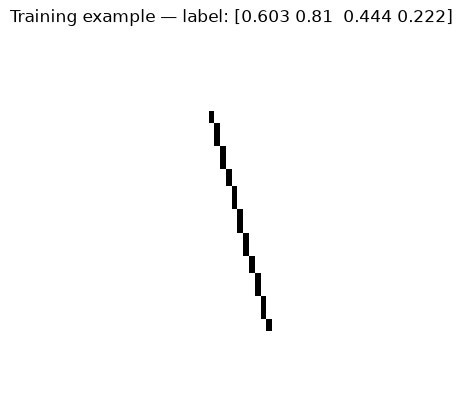

In [5]:
index = 0

plt.imshow(X_train[index].squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title(f"Training example — label: {np.round(y_train[index], 3)}")
plt.axis("off")
plt.show()

## Build the CNN vector model

The CNN predicts four numbers:

```text
[x1, y1, x2, y2]
```

In [6]:
def build_vector_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="raster_input")

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.Flatten()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)

    vector_output = layers.Dense(4, activation="sigmoid", name="vector_output")(x)

    return models.Model(inputs=inputs, outputs=vector_output, name="vector_model")


vector_model = build_vector_model()
vector_model.summary()

Model: "vector_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ raster_input (InputLayer)            │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vector_output (Dense)                │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,371,076 (9.04 MB)

 Trainable params: 2,371,076 (9.04 MB)

 Non-trainable params: 0 (0.00 B)

## Coordinate loss

A line is the same line if its endpoints are swapped, so this loss checks both endpoint orders and uses whichever is better.

In [7]:
def line_coordinate_loss(y_true, y_pred):
    direct_loss = tf.reduce_mean(tf.square(y_true - y_pred), axis=-1)

    reversed_pred = tf.stack([
        y_pred[:, 2],
        y_pred[:, 3],
        y_pred[:, 0],
        y_pred[:, 1],
    ], axis=1)

    reversed_loss = tf.reduce_mean(tf.square(y_true - reversed_pred), axis=-1)

    return tf.reduce_mean(tf.minimum(direct_loss, reversed_loss))

## Stage 1 — train the CNN on vector coordinates first

This prevents the raster model from collapsing into a fuzzy dot.

In [8]:
vector_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=line_coordinate_loss,
    metrics=["mae"]
)

history_vector = vector_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=VECTOR_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0170 - mae: 0.2173 - val_loss: 0.0038 - val_mae: 0.1959
Epoch 2/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0025 - mae: 0.1989 - val_loss: 0.0022 - val_mae: 0.1900
Epoch 3/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0018 - mae: 0.1974 - val_loss: 0.0025 - val_mae: 0.1961
Epoch 4/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0024 - mae: 0.1996 - val_loss: 0.0026 - val_mae: 0.1947
Epoch 5/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0020 - mae: 0.1980 - val_loss: 0.0018 - val_mae: 0.1931
Epoch 6/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0014 - mae: 0.1945 - val_loss: 0.0012 - val_mae: 0.1866
Epoch 7/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0019 - mae: 0.1957 - val_loss: 0.0011 - val_mae: 0.1874
Epoch 8/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0020 - mae: 0.1958 - val_loss: 0.0013 - val_mae: 0.1896
Epoch 9/150
157/157 ━━━━━━━━━━━━━━━━━━━━

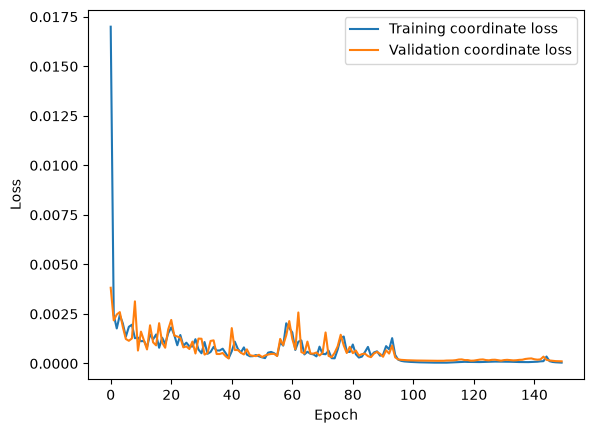

In [9]:
plt.plot(history_vector.history["loss"], label="Training coordinate loss")
plt.plot(history_vector.history["val_loss"], label="Validation coordinate loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Differentiable rasteriser

This layer converts predicted vector coordinates back into a soft raster image using TensorFlow maths.

Because it is TensorFlow-based, backpropagation can pass through it.

In [10]:
class DifferentiableLineRasteriser(layers.Layer):
    def __init__(self, img_size=64, sigma=0.010, **kwargs):
        super().__init__(**kwargs)
        self.img_size = img_size
        self.sigma = sigma

        xs = tf.linspace(0.0, 1.0, img_size)
        ys = tf.linspace(0.0, 1.0, img_size)
        grid_x, grid_y = tf.meshgrid(xs, ys)

        self.grid_x = tf.reshape(grid_x, (1, img_size, img_size))
        self.grid_y = tf.reshape(grid_y, (1, img_size, img_size))

    def call(self, vectors):
        x1 = tf.reshape(vectors[:, 0], (-1, 1, 1))
        y1 = tf.reshape(vectors[:, 1], (-1, 1, 1))
        x2 = tf.reshape(vectors[:, 2], (-1, 1, 1))
        y2 = tf.reshape(vectors[:, 3], (-1, 1, 1))

        px = self.grid_x
        py = self.grid_y

        dx = x2 - x1
        dy = y2 - y1

        length_squared = dx * dx + dy * dy + 1e-8

        t = ((px - x1) * dx + (py - y1) * dy) / length_squared
        t = tf.clip_by_value(t, 0.0, 1.0)

        closest_x = x1 + t * dx
        closest_y = y1 + t * dy

        distance_squared = tf.square(px - closest_x) + tf.square(py - closest_y)

        line_darkness = tf.exp(-distance_squared / (2.0 * self.sigma * self.sigma))

        raster = 1.0 - line_darkness
        raster = tf.expand_dims(raster, axis=-1)

        return raster

## Weighted raster loss

Normal MSE performs badly because most pixels are white. This weighted loss gives black line pixels much more importance.

In [11]:
def weighted_raster_loss(y_true, y_pred):
    black_pixel_weight = 40.0
    weights = 1.0 + black_pixel_weight * (1.0 - y_true)
    loss = weights * tf.square(y_true - y_pred)
    return tf.reduce_mean(loss)

## Stage 2 — train through the differentiable rasteriser

This model has two losses:

1. Raster loss: predicted raster should match the input raster.
2. Coordinate loss: predicted vector should not drift away from the true vector.

The raster loss is the important Option B part.

In [12]:
raster_output = DifferentiableLineRasteriser(
    img_size=IMG_SIZE,
    sigma=0.010,
    name="raster_output"
)(vector_model.output)

training_model = models.Model(
    inputs=vector_model.input,
    outputs=[raster_output, vector_model.output],
    name="option_b_training_model"
)

training_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=[weighted_raster_loss, line_coordinate_loss],
    loss_weights=[1.0, 0.2],
    metrics=[["mae"], ["mae"]]
)

history_raster = training_model.fit(
    X_train,
    [X_train, y_train],
    validation_data=(X_test, [X_test, y_test]),
    epochs=RASTER_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0172 - raster_output_loss: 0.0172 - raster_output_mae: 0.0086 - vector_output_loss: 3.5165e-05 - vector_output_mae: 0.1855 - val_loss: 0.0285 - val_raster_output_loss: 0.0283 - val_raster_output_mae: 0.0093 - val_vector_output_loss: 9.0401e-05 - val_vector_output_mae: 0.1880
Epoch 2/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0145 - raster_output_loss: 0.0145 - raster_output_mae: 0.0085 - vector_output_loss: 3.5681e-05 - vector_output_mae: 0.1859 - val_loss: 0.0275 - val_raster_output_loss: 0.0274 - val_raster_output_mae: 0.0093 - val_vector_output_loss: 9.1591e-05 - val_vector_output_mae: 0.1882
Epoch 3/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0133 - raster_output_loss: 0.0133 - raster_output_mae: 0.0084 - vector_output_loss: 3.6663e-05 - vector_output_mae: 0.1861 - val_loss: 0.0271 - val_raster_output_loss: 0.0269 - val_raster_output_mae: 0.0093 - val_vector_output_loss: 9.1897e-05 - val_vecto

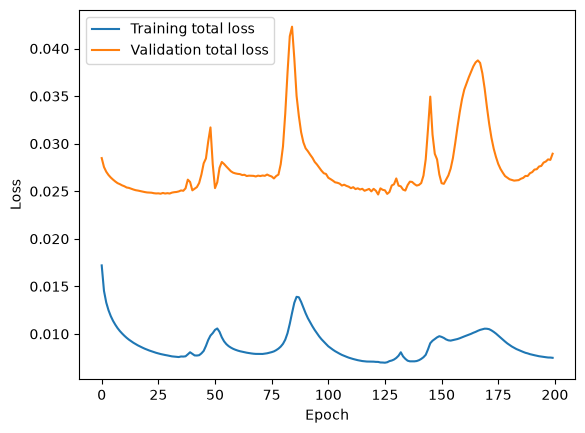

In [13]:
plt.plot(history_raster.history["loss"], label="Training total loss")
plt.plot(history_raster.history["val_loss"], label="Validation total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Test the trained model

True vector:      [0.921 0.651 0.81  1.   ]
Predicted vector: [0.932 0.669 0.802 0.998]
True pixels:      [58 41 51 63]
Predicted pixels: [59 42 51 63]


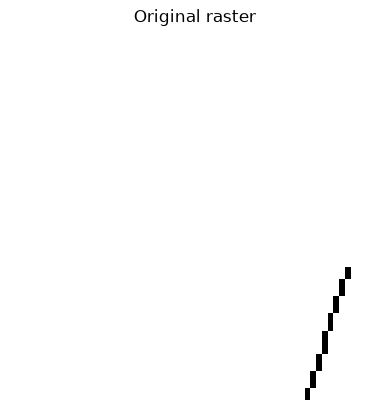

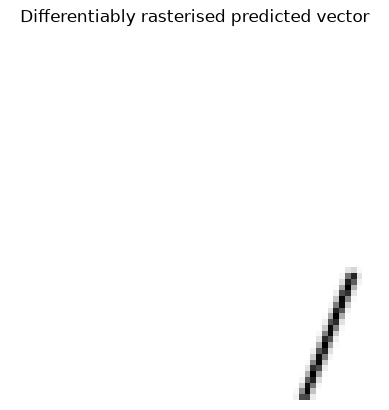

In [14]:
raster_model = models.Model(
    inputs=vector_model.input,
    outputs=raster_output,
    name="raster_prediction_model"
)

sample_index = 0
sample = X_test[sample_index:sample_index + 1]
true_vector = y_test[sample_index]

predicted_vector = vector_model.predict(sample, verbose=0)[0]
predicted_raster = raster_model.predict(sample, verbose=0)[0]

print("True vector:     ", np.round(true_vector, 3))
print("Predicted vector:", np.round(predicted_vector, 3))
print("True pixels:     ", np.round(true_vector * (IMG_SIZE - 1)).astype(int))
print("Predicted pixels:", np.round(predicted_vector * (IMG_SIZE - 1)).astype(int))

plt.imshow(sample.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title("Original raster")
plt.axis("off")
plt.show()

plt.imshow(predicted_raster.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title("Differentiably rasterised predicted vector")
plt.axis("off")
plt.show()

## Compare several predictions

Example 0
True pixels:      [58 41 51 63]
Predicted pixels: [59 42 51 63]


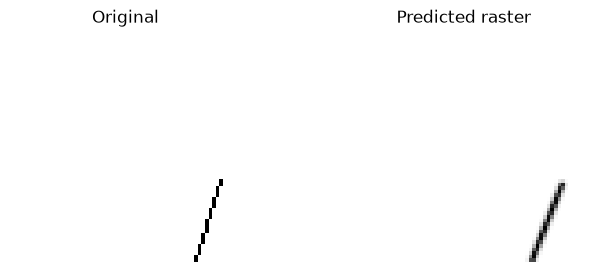

Example 1
True pixels:      [62 60 55 40]
Predicted pixels: [62 61 54 39]


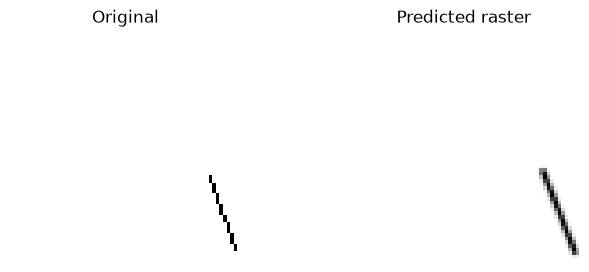

Example 2
True pixels:      [33 38 40 56]
Predicted pixels: [40 56 33 38]


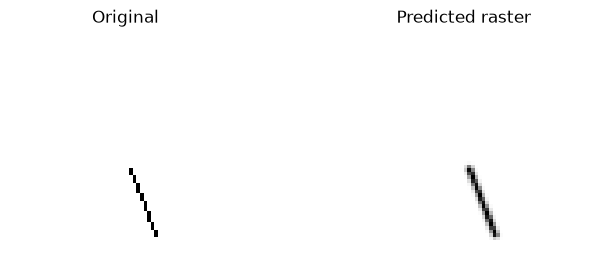

Example 3
True pixels:      [43 36  0 53]
Predicted pixels: [43 37  0 53]


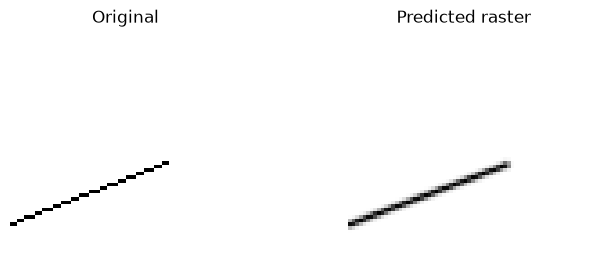

Example 4
True pixels:      [17 44 28 31]
Predicted pixels: [28 31 17 44]


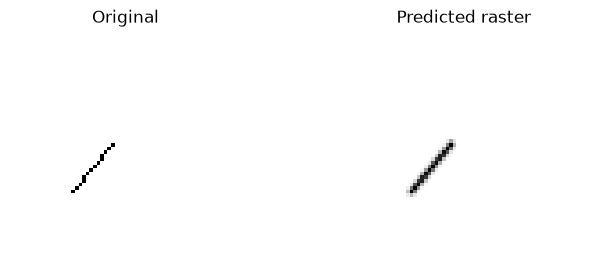

In [15]:
for sample_index in range(5):
    sample = X_test[sample_index:sample_index + 1]
    true_vector = y_test[sample_index]
    predicted_vector = vector_model.predict(sample, verbose=0)[0]
    predicted_raster = raster_model.predict(sample, verbose=0)[0]

    print("Example", sample_index)
    print("True pixels:     ", np.round(true_vector * (IMG_SIZE - 1)).astype(int))
    print("Predicted pixels:", np.round(predicted_vector * (IMG_SIZE - 1)).astype(int))

    plt.figure(figsize=(8, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(sample.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_raster.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title("Predicted raster")
    plt.axis("off")

    plt.show()

## Export the predicted line as SVG

In [16]:
def vector_to_svg(vector, img_size=64):
    x1, y1, x2, y2 = np.round(vector * (img_size - 1)).astype(int)

    svg = (
        f'<svg width="{img_size}" height="{img_size}" xmlns="http://www.w3.org/2000/svg">\n'
        f'  <rect width="100%" height="100%" fill="white"/>\n'
        f'  <line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" stroke="black" stroke-width="1"/>\n'
        f'</svg>'
    )

    return svg

svg_text = vector_to_svg(predicted_vector, IMG_SIZE)
print(svg_text)

with open("predicted_line.svg", "w") as f:
    f.write(svg_text)

print("Saved predicted_line.svg")

<svg width="64" height="64" xmlns="http://www.w3.org/2000/svg">
  <rect width="100%" height="100%" fill="white"/>
  <line x1="28" y1="31" x2="17" y2="44" stroke="black" stroke-width="1"/>
</svg>
Saved predicted_line.svg


## What to change next

To train for longer, edit these values near the top of the notebook:

```python
VECTOR_EPOCHS = 150
RASTER_EPOCHS = 200
```

If the line is still too blurry, try reducing:

```python
sigma=0.010
```

to:

```python
sigma=0.007
```

inside the `DifferentiableLineRasteriser(...)` call.